In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [25]:
# Load dataset
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


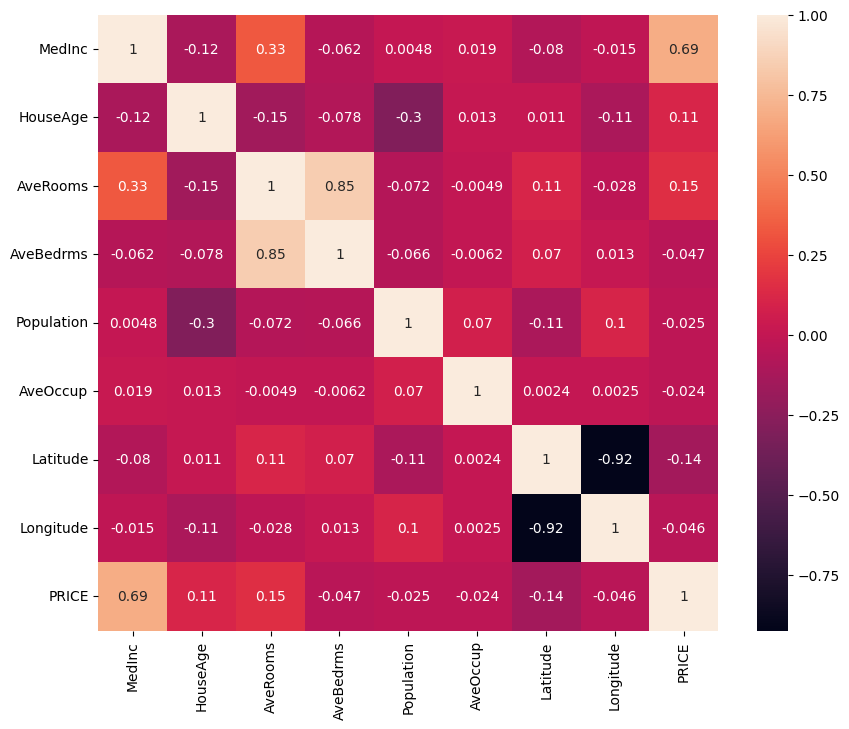

In [26]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [27]:
# Split data
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train Score:', lr.score(X_train, y_train))
print('Test Score:', lr.score(X_test, y_test))

Train Score: 0.6093459727972159
Test Score: 0.5957702326061665


In [30]:

# Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

print('Train Score:', ridge.score(X_train, y_train))
print('Test Score:', ridge.score(X_test, y_test))

Train Score: 0.6093371291442486
Test Score: 0.5959440604913041


In [31]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print('Train Score:', lasso.score(X_train, y_train))
print('Test Score:', lasso.score(X_test, y_test))

Train Score: 0.4938699875226863
Test Score: 0.49349221700165646


In [32]:
# Create coefficient comparison table
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Set feature as index (optional, cleaner view)
coef_df.set_index("Feature", inplace=True)

# Display table
coef_df

,Linear,Ridge,Lasso
Feature,,,
MedInc,0.849222,0.848519,0.708327
HouseAge,0.122119,0.123001,0.106594
AveRooms,-0.299558,-0.297069,-0.000000
AveBedrms,0.348410,0.345349,0.000000
Population,-0.000884,-0.000585,-0.000000
AveOccup,-0.041698,-0.041741,-0.000000
Latitude,-0.893856,-0.885416,-0.010425
Longitude,-0.868617,-0.860056,-0.000000


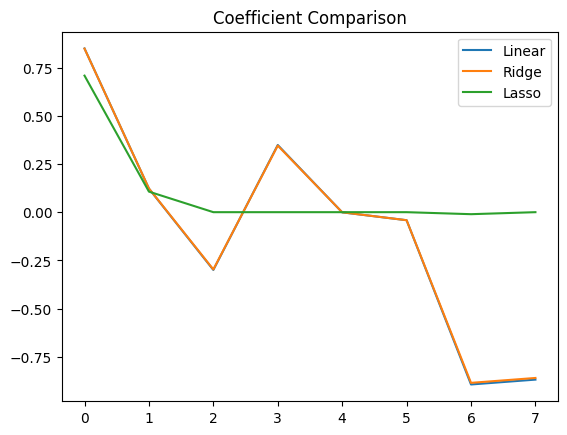

In [33]:
# Compare coefficients
plt.figure()
plt.plot(lr.coef_, label='Linear')
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')
plt.legend()
plt.title('Coefficient Comparison')
plt.show()

In [42]:
df1 = pd.read_csv("Salary.csv")
df1

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [43]:
df1.info

<bound method DataFrame.info of       Age  Gender Education Level                      Job Title  \
0    32.0    Male      Bachelor's              Software Engineer   
1    28.0  Female        Master's                   Data Analyst   
2    45.0    Male             PhD                 Senior Manager   
3    36.0  Female      Bachelor's                Sales Associate   
4    52.0    Male        Master's                       Director   
..    ...     ...             ...                            ...   
370  35.0  Female      Bachelor's       Senior Marketing Analyst   
371  43.0    Male        Master's         Director of Operations   
372  29.0  Female      Bachelor's         Junior Project Manager   
373  34.0    Male      Bachelor's  Senior Operations Coordinator   
374  44.0  Female             PhD        Senior Business Analyst   

     Years of Experience    Salary  
0                    5.0   90000.0  
1                    3.0   65000.0  
2                   15.0  150000.0  
3  

In [45]:
df1.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [56]:
df1.dropna(inplace = True)
df1.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [57]:
df1.duplicated().sum()

np.int64(49)

In [58]:
df1.drop_duplicates(inplace=True)
df1.duplicated().sum()

np.int64(0)

In [59]:
df1.shape

(324, 6)

In [60]:
df1.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

In [62]:
df1.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


<Axes: >

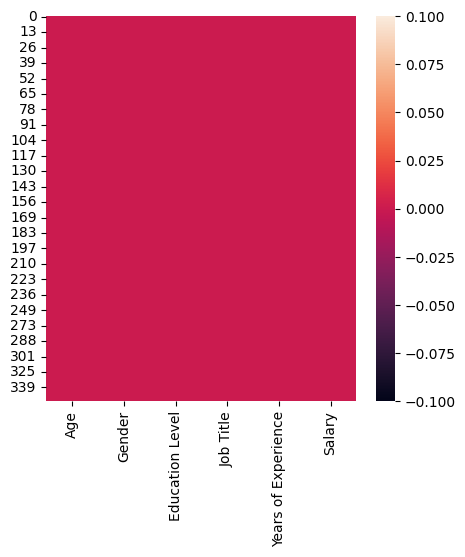

In [65]:
plt.figure(figsize=(5,5))
sns.heatmap(df1.isnull())

In [82]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)
df1.head(5)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [84]:
df1 = pd.get_dummies(df1 , columns=['Gender'], drop_first=False)

In [86]:
df1.head(10)

,Age,Education Level,Job Title,Years of Experience,Salary,Gender_Female,Gender_Male
0,32.0,Bachelor's,Software Engineer,5.0,90000.0,False,True
1,28.0,Master's,Data Analyst,3.0,65000.0,True,False
2,45.0,PhD,Senior Manager,15.0,150000.0,False,True
3,36.0,Bachelor's,Sales Associate,7.0,60000.0,True,False
4,52.0,Master's,Director,20.0,200000.0,False,True
5,29.0,Bachelor's,Marketing Analyst,2.0,55000.0,False,True
6,42.0,Master's,Product Manager,12.0,120000.0,True,False
7,31.0,Bachelor's,Sales Manager,4.0,80000.0,False,True
8,26.0,Bachelor's,Marketing Coordinator,1.0,45000.0,True,False
9,38.0,PhD,Senior Scientist,10.0,110000.0,False,True


In [87]:
df1.dtypes

Age                    float64
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
Gender_Female             bool
Gender_Male               bool
dtype: object

In [ ]:
df